In [1]:
import pandas as pd

df = pd.read_csv("/home/thinkpad/Documents/BrototypeStudying/Paper two/week 8/code/data/raw_employee_data.csv")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         508 non-null    str    
 1   name                508 non-null    str    
 2   email               498 non-null    str    
 3   phone               493 non-null    str    
 4   age                 488 non-null    float64
 5   gender              498 non-null    str    
 6   department          498 non-null    str    
 7   city                498 non-null    str    
 8   education           493 non-null    str    
 9   years_experience    491 non-null    float64
 10  performance_rating  498 non-null    float64
 11  remote_work         484 non-null    float64
 12  join_date           498 non-null    str    
 13  salary              483 non-null    str    
 14  notes               201 non-null    str    
dtypes: float64(4), str(11)
memory usage: 59.7 KB


In [2]:
df = df.dropna(subset="salary")

In [3]:
df.isnull().sum()

employee_id             0
name                    0
email                  10
phone                  15
age                    20
gender                 10
department             10
city                    9
education              14
years_experience       17
performance_rating     10
remote_work            21
join_date               9
salary                  0
notes                 298
dtype: int64

In [4]:
df = df.drop(columns=["employee_id", "name", "email", "phone", "gender", "education", "join_date", "notes","performance_rating"])

In [5]:
df.isnull().sum()

age                 20
department          10
city                 9
years_experience    17
remote_work         21
salary               0
dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=["salary"])
y = df["salary"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
x_train.info()
x_train.isnull().sum()

<class 'pandas.DataFrame'>
Index: 386 entries, 432 to 109
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               372 non-null    float64
 1   department        378 non-null    str    
 2   city              377 non-null    str    
 3   years_experience  370 non-null    float64
 4   remote_work       372 non-null    float64
dtypes: float64(3), str(2)
memory usage: 18.1 KB


age                 14
department           8
city                 9
years_experience    16
remote_work         14
dtype: int64

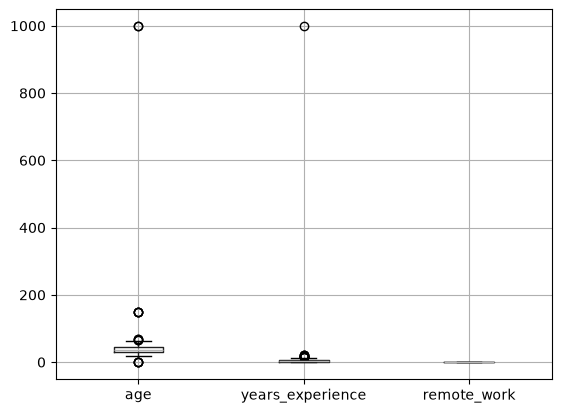

In [8]:
import matplotlib.pyplot as plt

x_train.boxplot()
plt.show()

In [9]:
# median_age = df["age"].median()
# df.loc[df["age"] > 100 , "age"] = median_age
# df.loc[df["age"] > 100, "age"]

In [10]:
median_age = x_train["age"].median()

In [11]:
Q1 = x_train["age"].quantile(0.25)
Q3 = x_train["age"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outlier = x_train[(df["age"] < lower_bound) | (df["age"] > upper_bound)]

print(outlier)

       age       department      city  years_experience  remote_work
417    0.0        marketing    Austin               1.0          0.0
213  999.0         Markting  new york              20.0          0.0
452    0.0      ENGINEERING   seattle               1.0          1.0
156   66.0            sales    Boston               2.0          0.0
173    0.0          FINANCE    Boston               1.0          0.0
420    0.0          support   houston               0.0          0.0
71    69.0  Human Resources   austin                3.0          0.0
92    67.0            Sales   CHICAGO               4.0          0.0
57   150.0      Engineering    denver               3.0          0.0
479  150.0  Human Resources    Boston               0.0          0.0
338  150.0          support   chicago               1.0          0.0
465   70.0        marketing    Boston               0.0          0.0
200  999.0            sales   houston              12.0          1.0
363  150.0             I.T.     MI

/tmp/ipykernel_22100/1752031340.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outlier = x_train[(df["age"] < lower_bound) | (df["age"] > upper_bound)]


In [12]:
x_train.dtypes

age                 float64
department              str
city                    str
years_experience    float64
remote_work         float64
dtype: object

In [13]:
x_train.loc[x_train["age"] > 100, "age"] = median_age

In [14]:
x_test.loc[x_test["age"] > 100, "age"] = median_age

In [15]:
x_train["age"].dtype
x_test["age"].dtype

dtype('float64')

In [16]:
x_train["age"] = x_train["age"].fillna(x_train["age"].median())
x_test["age"] = x_test["age"].fillna(x_train["age"].median())

In [17]:
x_train.isnull().sum()
# x_test.isnull().sum()

age                  0
department           8
city                 9
years_experience    16
remote_work         14
dtype: int64

In [18]:
department_mode = x_train["department"].mode()[0]

In [19]:
x_train["department"] = x_train["department"].fillna(department_mode)
x_test["department"] = x_test["department"].fillna(department_mode)

In [20]:
x_train.isnull().sum()
# x_test.isnull().sum()

age                  0
department           0
city                 9
years_experience    16
remote_work         14
dtype: int64

In [21]:
x_train["city"].mode()[0]

'Denver'

In [22]:
x_train["city"] = x_train["city"].fillna(x_train["city"].mode()[0])
x_test["city"] = x_test["city"].fillna(x_train["city"].mode()[0])

In [23]:
Q1 = df["years_experience"].quantile(0.25)
Q3 = df["years_experience"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier = df[(df["years_experience"] < lower_bound )|(df["years_experience"] > upper_bound )]
print(lower_bound,upper_bound)
print(outlier)

-6.5 13.5
       age       department      city  years_experience  remote_work  \
39    43.0              Ops   houston              19.0          0.0   
40    44.0          finance   Chicago              15.0          0.0   
59    48.0          Finance   seattle              14.0          0.0   
61    43.0      Engineering    boston             999.0          1.0   
165   43.0               it    Denver              22.0          0.0   
188   37.0  Human Resources   austin               16.0          0.0   
201   50.0          support   houston              19.0          0.0   
213  999.0         Markting  new york              20.0          0.0   
235   44.0               hr   seattle              20.0          1.0   
260   50.0              NaN   chicago              16.0          0.0   
271    NaN      Engineering       NYC              15.0          0.0   
281   41.0      Engineering    Denver              20.0          0.0   
297   41.0        Marketing   CHICAGO              19.

In [24]:
# #Check every row - is years_experience impossible for that person's age?
# invalid_age = df["years_experience"] > (df["age"] - 18)

# #For only the broken rows, fix years_experience = age - 18 (never below 0)
# df.loc[invalid_age, "years_experience"] = (df.loc[invalid_age, "age"] - 18).clip(lower=0)

# df.loc[df["years_experience"] > 60, "years_experience"] = df["years_experience"].median()
# df.loc[df["years_experience"] < 0, "years_experience"] = df["years_experience"].median()

In [25]:
result = pd.merge(x_train, y_train, left_index=True,right_index=True,how="inner")
print(result.head(5))

      age   department     city  years_experience  remote_work     salary
432  36.0  ENGINEERING  seattle               4.0          0.0  109508.58
28   28.0       Suport    miami               0.0          0.0   53857.62
232  55.0           IT  CHICAGO               0.0          1.0   76088.32
416  41.0        sales  Seattle               0.0          1.0   83627.95
243  52.0      finance   denver               2.0          1.0   76946.48


In [26]:
x_train["years_experience"] = x_train["years_experience"].fillna(x_train["years_experience"].median())
x_test["years_experience"] = x_test["years_experience"].fillna(x_train["years_experience"].median())

In [27]:
x_train.isnull().sum()
x_test.isnull().sum()

age                 0
department          0
city                0
years_experience    0
remote_work         7
dtype: int64

In [28]:
mode_remoteWork = x_train["remote_work"].mode()[0]
x_train["remote_work"] = x_train["remote_work"].fillna(mode_remoteWork)
x_test["remote_work"] = x_test["remote_work"].fillna(mode_remoteWork)

In [29]:
invalid_value = x_train["years_experience"] > (x_train["age"] - 18)
x_train.loc[invalid_value, "years_experience"] = (x_train.loc[invalid_value, "age"] - 18).clip(lower=0)

in_test_invalid_value = x_test["years_experience"] > (x_test["age"] - 18)
x_test.loc[in_test_invalid_value, "years_experience"] = (x_test.loc[in_test_invalid_value, "age"] - 18).clip(lower=0)


In [30]:
# def remove_expOutliers(dataset,column):
#     dataset.loc[dataset[column] > 60,"age"] = dataset[column].median()
#     return dataset

# remove_expOutliers(x_train,"age")

In [31]:
x_train.loc[df["age"] < 18 ,"age"] = x_train["age"].median()

In [32]:
# x_train.groupby("age").size()

In [33]:
x_train[x_train["years_experience"] > 15]

,age,department,city,years_experience,remote_work
213,36.0,Markting,new york,18.0,0.0
436,42.0,Markting,MIAMI,17.0,0.0
235,44.0,hr,seattle,20.0,1.0
188,37.0,Human Resources,austin,16.0,0.0
39,43.0,Ops,houston,19.0,0.0
165,43.0,it,Denver,22.0,0.0


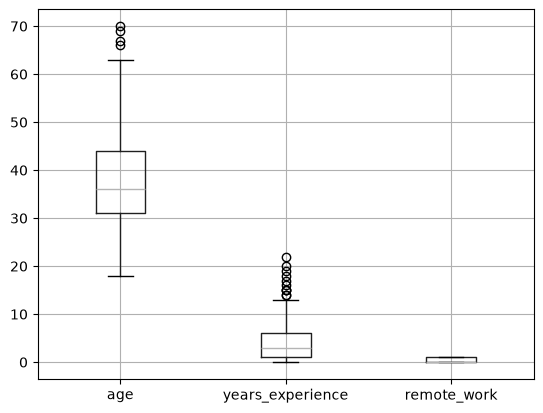

In [34]:
x_train.boxplot()
plt.show()

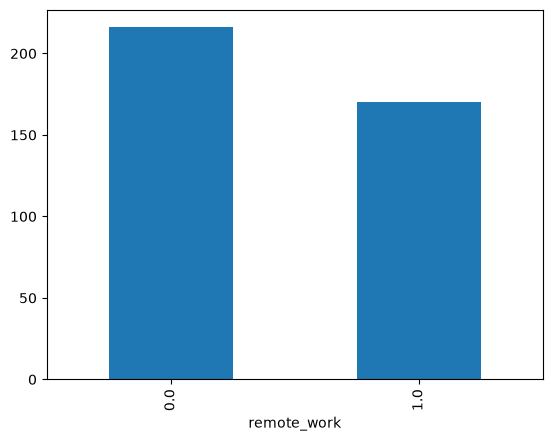

In [35]:
x_train["remote_work"].value_counts().plot(kind="bar")
plt.show()

In [36]:
y_train.info()

<class 'pandas.Series'>
Index: 386 entries, 432 to 109
Series name: salary
Non-Null Count  Dtype
--------------  -----
386 non-null    str  
dtypes: str(1)
memory usage: 14.1 KB


In [37]:
y_train = y_train.astype(str).str.replace(r'[^\d.]',"",regex = True).astype(float)
y_train = y_train.astype(int)
print(y_train.dtype)
y_test = y_test.astype(str).str.replace(r'[^\d.]',"",regex = True).astype(float).astype(int)


int64


In [38]:
y_train.groupby(x_train["remote_work"]).mean()

remote_work
0.0    102285.819444
1.0     76895.205882
Name: salary, dtype: float64

In [39]:
x_train["department"].unique()

<StringArray>
[    'ENGINEERING',          'Suport',              'IT',           'sales',
         'finance',        'Markting',              'it',      'Operations',
         'Finance', 'Human Resources',         'support',    ' Engineering',
       'Marketing',          'Sales ',         'Support',       'marketing',
     'engineering',              'hr',              'HR',     'Engineering',
         'FINANCE',           'Sales',             'Ops',           'SALES',
            'I.T.',      'operations',            'H.R.']
Length: 27, dtype: str

In [40]:
x_train["department"] = x_train["department"].str.strip().str.lower()

In [ ]:
dept_map = {
    "suport" : "support",
    "i.t." : "it",
    "human resources" : "hr",
    "h.r." : "hr",
    "markting" : "marketing",
    "ops" : "operations"
}

x_train["department"] = x_train["department"].replace(dept_map)

In [42]:
x_train["city"].unique()

<StringArray>
[ 'seattle',    'miami',  'CHICAGO',  'Seattle',   'denver',   'Denver',
   'austin',  'chicago',  'Phoenix',   'Boston',   'boston',  'austin ',
  'Houston',  'houston',   'Austin', 'New york',    'Miami', 'New York',
    'MIAMI',      'NYC', 'new york',  'Chicago', 'NEW YORK',  'phoenix']
Length: 24, dtype: str

In [43]:
x_train["city"] = x_train["city"].str.strip().str.lower()

In [44]:
city_map = {
    "nyc" : "new york"
}

x_train["city"] = x_train["city"].replace(city_map)

In [45]:
x_train["city"].value_counts()

city
denver      57
austin      47
new york    46
seattle     41
chicago     41
houston     41
miami       40
phoenix     37
boston      36
Name: count, dtype: int64

In [46]:
x_test["department"].unique()

<StringArray>
['Human Resources',     'engineering',       'Marketing',           'sales',
         'FINANCE',             'Ops',         'finance',              'IT',
      'Operations',         'support',       'marketing',      'operations',
        'Markting',         'Support',            'H.R.',         'Finance',
              'it',          'Suport',     'Engineering',           'Sales',
           'SALES',     'ENGINEERING',            'I.T.',    ' Engineering',
              'hr',          'Sales ']
Length: 26, dtype: str

In [47]:
x_test["department"] = x_test["department"].str.strip().str.lower()
x_test["department"] = x_test["department"].replace(dept_map)

In [48]:
x_test["city"].unique()

<StringArray>
[ 'CHICAGO',  'houston',  'seattle',  'chicago',   'Austin',   'Boston',
  'phoenix',  'austin ',   'austin',      'NYC',    'miami',   'boston',
   'denver',    'MIAMI',  'Seattle',  'Houston', 'New York',  'Phoenix',
  'Chicago',   'Denver',    'Miami', 'NEW YORK']
Length: 22, dtype: str

In [49]:
x_test["city"] = x_test["city"].str.strip().str.lower()
x_test["city"] = x_test["city"].replace(city_map)

In [50]:
x_train = pd.get_dummies(x_train, columns=["department", "city"], drop_first=True).astype(int)
x_test = pd.get_dummies(x_test, columns=["department", "city"], drop_first=True).astype(int)

In [51]:
y_train.describe().round(2)

count        386.00
mean       91103.42
std       136120.97
min        40756.00
25%        62842.75
50%        75653.50
75%        89249.50
max      1856172.00
Name: salary, dtype: float64

In [52]:
y_train = y_train.astype(float).astype(int)

In [53]:
y_train[y_train > 200000] = y_train.median().astype(int)

In [54]:
y_test[y_test > 200000] = y_train.median()

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_to_scale = ["age", "years_experience"]

x_train[cols_to_scale] = scaler.fit_transform(x_train[cols_to_scale])
x_test[cols_to_scale] = scaler.transform(x_test[cols_to_scale])


In [56]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train,y_train)

pred = model.predict(x_test)

In [57]:
from sklearn.metrics import mean_absolute_error,r2_score

print("MAE :", mean_absolute_error(y_test,pred))

print("R2 :", r2_score(y_test,pred))

MAE : 11100.01779874007
R2 : 0.3603872433797304


In [58]:
# from sklearn.ensemble import RandomForestRegressor

# model = RandomForestRegressor(n_estimators=200, random_state=42)
# model.fit(x_train, y_train)
# preds = model.predict(x_test)

# print("MAE:", mean_absolute_error(y_test, preds))
# print("R²:", r2_score(y_test, preds))

In [59]:
# importances = pd.Series(model.feature_importances_, index=x_train.columns).sort_values(ascending=False)
# print(importances)

In [60]:
# x_train = x_train.drop(columns=[c for c in x_train.columns if c.startswith("city_")])
# x_test = x_test.drop(columns=[c for c in x_test.columns if c.startswith("city_")])